In [1]:
import numpy as np 
import os 
import xarray as xr
import pandas as pd
#from scipy.io import savemat
from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib as mpl
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap

In [2]:
#Get merged data from USOS
all_days_filepath = '../../CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_30min/all_CSL_MobileLab_Parked_rev30minv4.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.set_index('time_local', inplace=True)

In [3]:
#Identify list of relevant VOCs we want data availability for
VOC_list = ['HCOOH_CIMS', 'Methanol_PTR', 'Acetonitrile_PTR', 'Acetaldehyde_PTR', 'Ethanol_PTR', 'Methanethiol_PTR', 
        'Acrolein_PTR', 'Acetone_Propanal_PTR', 'DMS_PTR', 'Isoprene_PTR', 'MVK_MACR_PTR', 'Benzene_PTR', 'Toluene_PTR', 
        'Styrene_PTR', 'C8Aromatics_PTR', 'C9Aromatics_PTR', 'Octanal_PTR', 
        'Monoterpenes_PTR', 'Nonanal_PTR', 'C7H4ClF3_PTR', 'D5_siloxane_PTR', 'C4H7NO5_CIMS', 'ISOPN_CIMS', 
        'C5H10O3_CIMS', 'C5H9NO5_CIMS', 'C10H17NO4_CIMS']

In [4]:
df_usos_vocs=pd.DataFrame(index=df_alldays.index)

for col in range(0, len(VOC_list)):
    # Everything that was a NaN or negative is assigned a 0, positive values are assigned a 1
    df_usos_vocs[VOC_list[col]] = np.where((df_alldays[VOC_list[col]] > 0) & (~df_alldays[VOC_list[col]].isna()), 1, 0 )

df_usos_vocs_transposed=df_usos_vocs.T

/var/folders/6m/87kslmb13vl09hjpjjpddb2h0000gn/T/ipykernel_13356/220371555.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_top.set_xticklabels(midnight_labels)


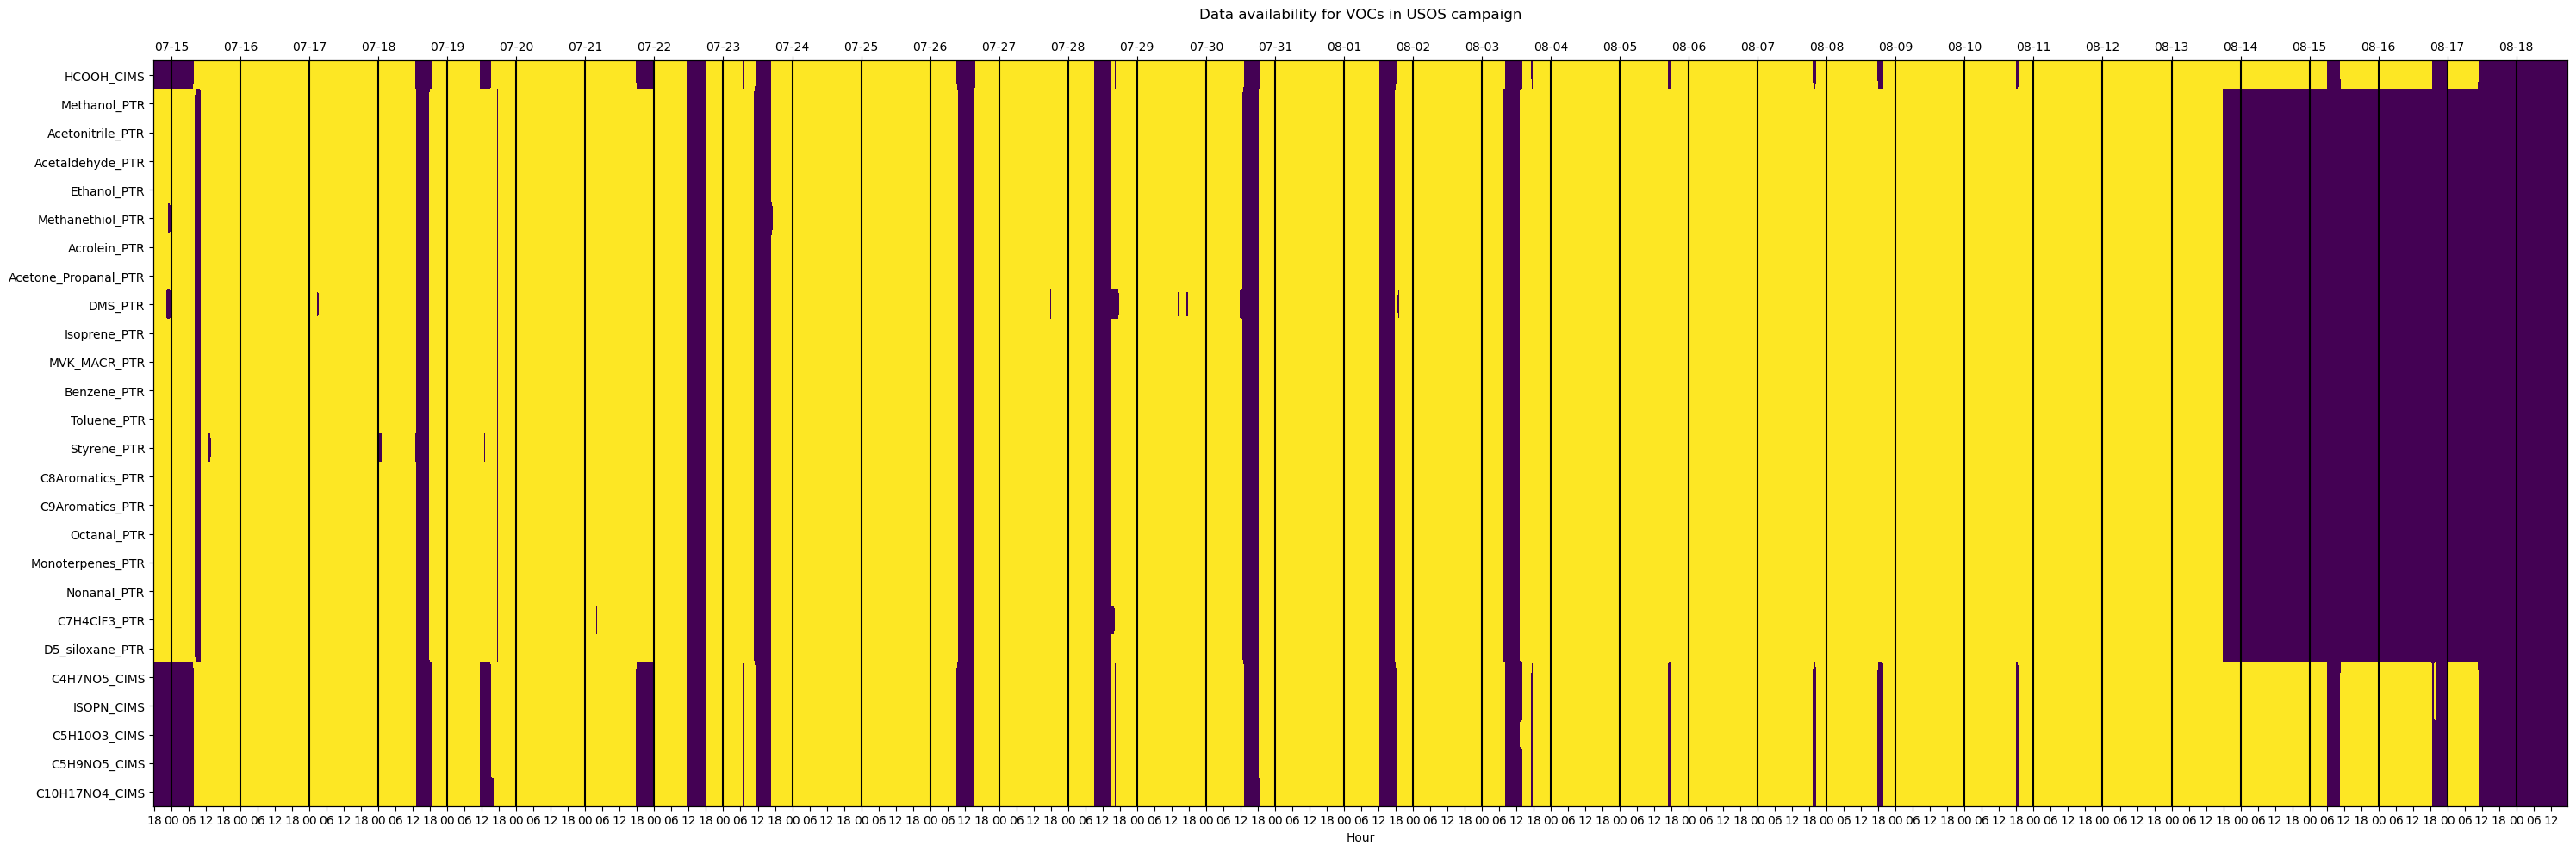

In [5]:
#alter viridis colormap to only have 2 color options
viridis = plt.cm.viridis
colors = [viridis(0.0), viridis(1.0)]
two_color_viridis = ListedColormap(colors)

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(df_usos_vocs_transposed, aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(df_usos_vocs_transposed.columns),12), labels=df_usos_vocs_transposed.columns.strftime('%H')[0::12])
ax.set_yticks(ticks=np.arange(len(df_usos_vocs_transposed.index)), labels=df_usos_vocs_transposed.index)
ax.set_xlabel('Hour')

for pos in range(12,len(df_usos_vocs_transposed.columns),48):
    plt.axvline(pos, color = 'black')
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
for date in range(12,len(df_usos_vocs_transposed.columns),48):
    date_labels = df_usos_vocs_transposed.columns.strftime('%m-%d')[date]
    midnight_labels.append(date_labels)

ax_top.set_xticklabels(midnight_labels)
ax_top.set_xticks(ticks=range(12,len(df_usos_vocs_transposed.columns),48))

# Set labels and title

plt.ylabel('Measurement')
plt.title('Data availability for VOCs in USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()

#save_filepath_merger = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_merges/data_availability_plots/three_day_availability_'+ str(date_to_plot) + '.png'
#plt.savefig(fname = save_filepath_merger,format='png')
#print('Saved figure as:' + str(save_filepath_merger))